# Education - Baselines
**Author:** Jiří Landsmann

Reference points for the simulation-based methods in `education.ipynb`. Target: share of population with tertiary education (%), known for the 14 Kraje, to be estimated for the 77 Okresy.

* **Kraj mean** - every Okres gets its region's official value. Any method must beat this.
* **Direct** - a regressor fitted on the 14 Kraj rows (features → official value) and applied to the Okresy. Shown raw and with **anchoring** (rescaled so the weighted Okres average equals the Kraj value).

**Evaluation protocol.** The real Okres values are used *only* to compute the metrics below -
never for fitting, clustering or tuning. Prague is both a Kraj and its only Okres, so every
anchored method reproduces it exactly; it is excluded from all metrics (76 districts remain).

| Metric | Meaning |
|---|---|
| MAE, RMSE | error in percentage points |
| R² | share of variance across all districts explained |
| Within-Kraj r | correlation of true vs. predicted *deviations from the Kraj value* - how well districts are ranked inside their region (NaN for the Kraj-mean baseline) |
| Anchor gap | largest difference between the weighted Okres average and the official Kraj value (0 = consistent with the official aggregate) |

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))  # repo root, for the shared `approx` package
import approx
from approx import plotting

RESULTS = Path("results")
PLOTS = Path("plots")
RESULTS.mkdir(exist_ok=True)
pd.set_option("display.precision", 3)

## 1. Data

**Features** - household composition from Census 2021, as shares of all households: one-family, multi-family and one-person households (the fourth category, multi-person non-family households, is implied because the shares sum to one).

**Weight** - number of households, used whenever Okres values are averaged up to a Kraj.

In [2]:
ds = approx.load_education()
print(f"{len(ds.okres)} okresy, {len(ds.kraj)} kraje, features: {ds.features}")
display(ds.kraj)

77 okresy, 14 kraje, features: ['share_one_family', 'share_multi_family', 'share_single_person']


,share_one_family,share_multi_family,share_single_person,weight,y
kraj,,,,,
hlavnimestopraha,0.492,0.007,0.469,658001,33.696
jihoceskykraj,0.593,0.016,0.376,284812,15.060
jihomoravskykraj,0.591,0.019,0.369,529939,20.707
karlovarskykraj,0.535,0.012,0.437,135416,9.641
krajvysocina,0.630,0.022,0.335,210806,13.448
kralovehradeckykraj,0.590,0.015,0.380,244683,13.905
libereckykraj,0.572,0.013,0.399,201102,13.206
moravskoslezskykraj,0.573,0.013,0.399,541276,15.413
olomouckykraj,0.594,0.015,0.375,280121,15.681


In [3]:
ds.okres.head(10)

,kraj,share_one_family,share_multi_family,share_single_person,weight,y_true
region,,,,,,
hlavnimestopraha,hlavnimestopraha,0.492,0.007,0.469,658001,33.696
benesov,stredoceskykraj,0.617,0.020,0.350,43227,14.341
beroun,stredoceskykraj,0.623,0.019,0.342,42130,16.651
kladno,stredoceskykraj,0.585,0.015,0.383,75857,14.628
kolin,stredoceskykraj,0.602,0.017,0.364,45778,13.655
kutnahora,stredoceskykraj,0.595,0.020,0.369,33297,12.772
melnik,stredoceskykraj,0.602,0.018,0.365,48834,13.220
mladaboleslav,stredoceskykraj,0.588,0.015,0.379,57859,14.088
nymburk,stredoceskykraj,0.606,0.016,0.362,44743,14.531


## 2. Run the baselines

In [4]:
baseline_preds = approx.run_baselines(ds)
baseline_table = approx.metrics_table(baseline_preds, ds, family="Baseline")
baseline_table

,Family,MAE,RMSE,R2,Within-Kraj r,Anchor gap
Method,,,,,,
Kraj mean,Baseline,2.976,3.833,0.107,NaN,1.776e-15
Direct Linear Regression,Baseline,1.695,2.245,0.694,0.809,2.200e+00
Direct Linear Regression + anchor,Baseline,1.435,1.872,0.787,0.862,3.553e-15
Direct Decision Tree,Baseline,4.179,5.840,-1.073,0.336,7.712e+00
Direct Decision Tree + anchor,Baseline,3.423,4.529,-0.247,0.364,3.553e-15
Direct Random Forest,Baseline,3.132,3.989,0.033,0.301,7.938e+00
Direct Random Forest + anchor,Baseline,2.873,3.627,0.200,0.324,7.105e-15
Direct Gradient Boosting,Baseline,3.315,4.305,-0.126,0.347,2.974e+00
Direct Gradient Boosting + anchor,Baseline,2.884,3.781,0.131,0.387,3.553e-15


Tree ensembles fitted on only 14 rows can barely generalise, and the raw direct models do not respect the official Kraj totals (non-zero anchor gap). Anchoring fixes the totals and lowers the error for every model.

## 3. Figures

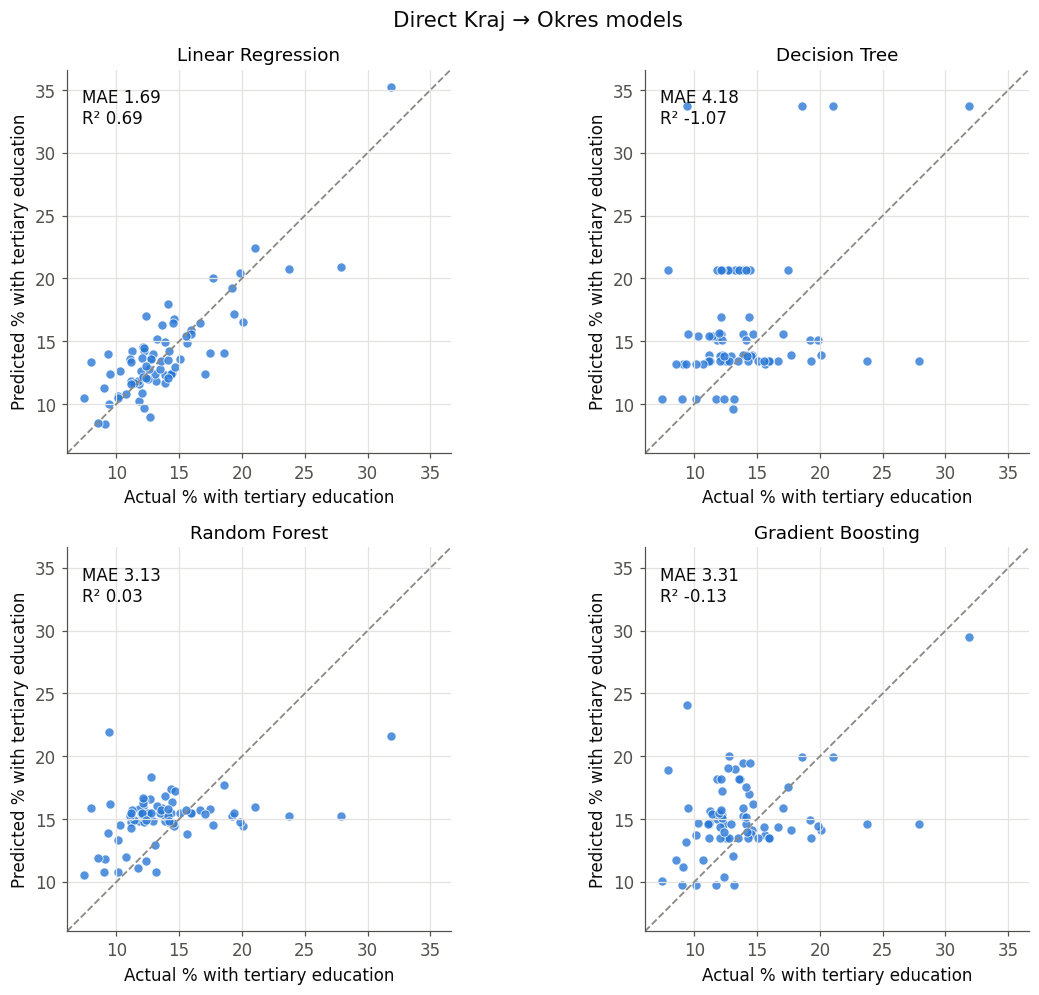

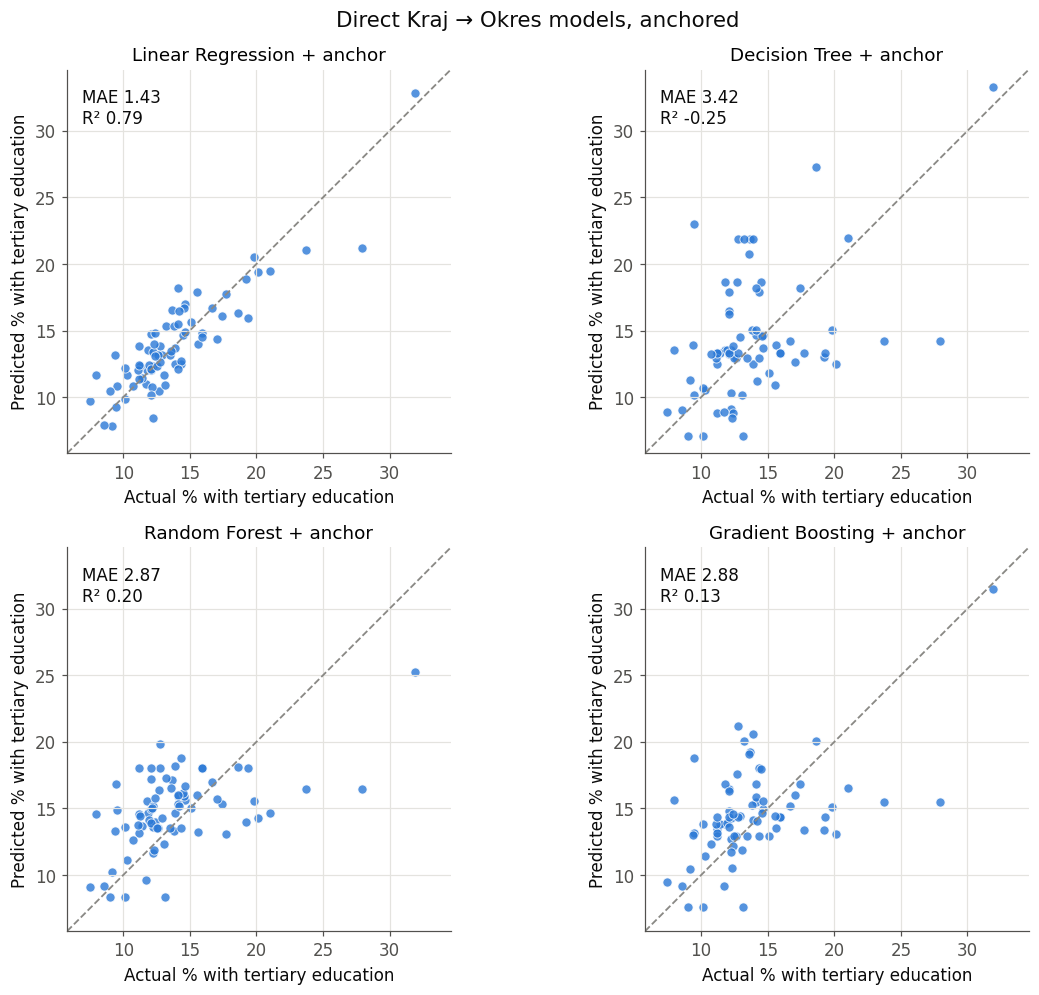

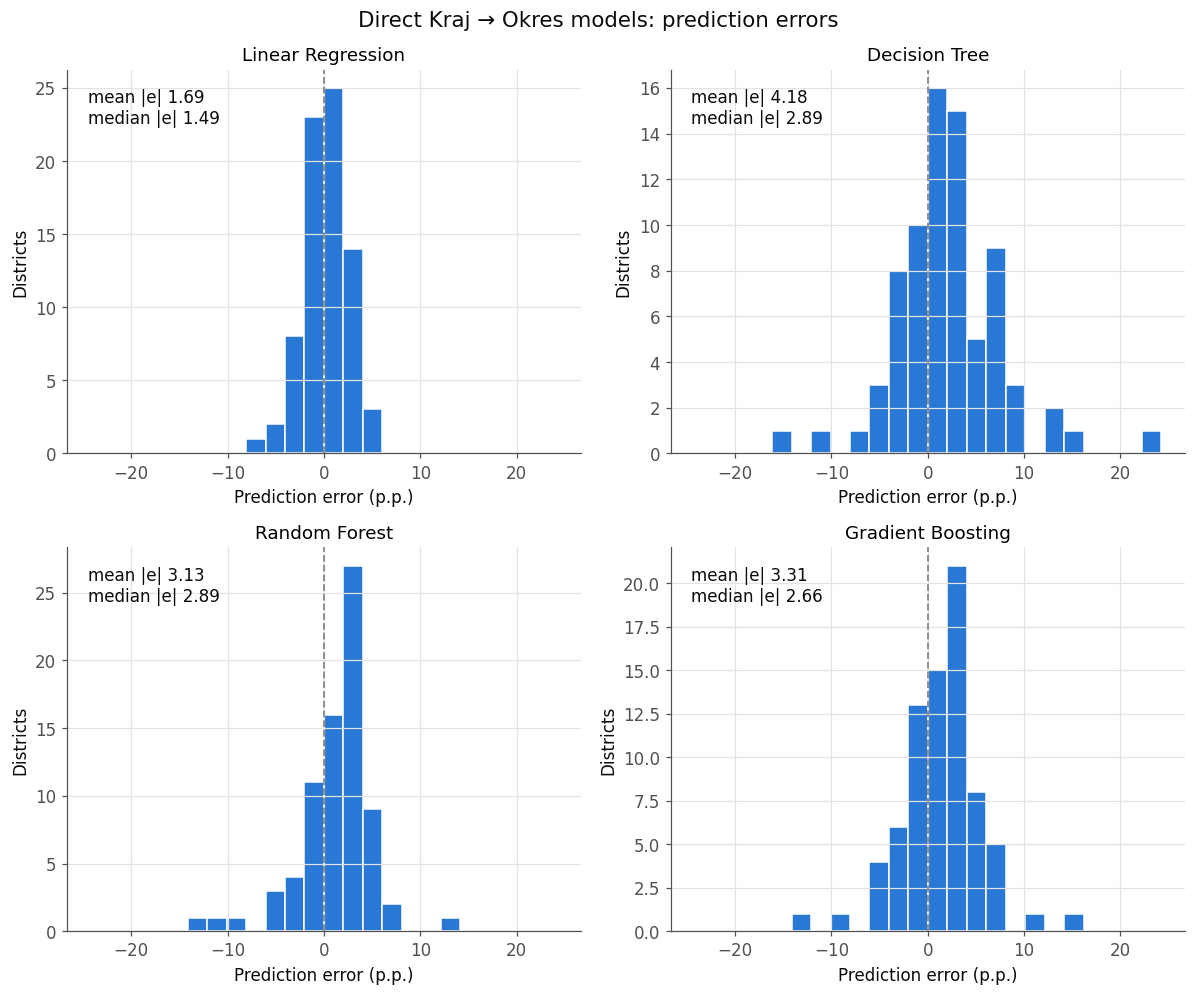

In [5]:
raw = {k.replace('Direct ', ''): v for k, v in baseline_preds.items()
       if k.startswith('Direct') and not k.endswith('anchor')}
anchored = {k.replace('Direct ', ''): v for k, v in baseline_preds.items() if k.endswith('anchor')}
plotting.prediction_grid(ds, raw, 'Direct Kraj → Okres models',
                         PLOTS / 'baseline_prediction_comparison.png');
plotting.prediction_grid(ds, anchored, 'Direct Kraj → Okres models, anchored',
                         PLOTS / 'baseline_anchored_prediction_comparison.png');
plotting.error_grid(ds, raw, 'Direct Kraj → Okres models: prediction errors',
                    PLOTS / 'baseline_error_distribution.png');

## 4. Save results

In [6]:
approx.predictions_frame(ds, baseline_preds).to_csv(RESULTS / 'baseline_predictions.csv')
baseline_table.to_csv(RESULTS / 'baseline_metrics.csv')